In [1]:
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, inv
import numpy as np

In [2]:
# Take minimum error for all positive and negative x
def min_error(x_hat, x_star):
    errors = []
    for x in x_hat:
            error_positive = np.linalg.norm(x_star - x)
            error_negative = np.linalg.norm(-1*x_star - x)
            errors.append(min(error_positive, error_negative))
    return errors

# Returns the convergence count for errors for a set of test parameters
def convergence_counts(errors, parameter, error_threshold = 1e-8):
    zero_error = {}
    for i in range(len(errors)):
        zero_error[parameter[i]] = 0
        for error in errors[i]:
            zero_error[parameter[i]] += error[-1] < error_threshold
    return zero_error

In [217]:
# Implements BWDG over a stochastic Subspace with thresholding
def bwgd_subspace_threshold(y, A, r, alpha=0, niter = 500):
    d, n = A.shape 
    x = np.zeros((niter, d))  
    threshold = int(alpha * n)

    # Spectral initialization
    Y = (1 / n) * (A @ np.diag(y) @ A.T)
    eigenvals, eigenvects = np.linalg.eigh(Y)
    index = np.argmax(eigenvals)  
    x[0] = np.sqrt(eigenvals[index] / 3) * eigenvects[:, index]

    for iter in range(1, niter):
        # Find indices for smallest |AtX|
        sorted_indices = np.argsort(np.abs(A.T @ x[iter - 1]))
        indices = sorted_indices[threshold:]

        # Discard the selected indices
        A_filtered = A.T[indices].T.copy()
        y_filtered = y[indices].copy()

        # Covariance matrix transform
        C = A_filtered @ A_filtered.T / n
        C_sqrt = sqrtm(C)
        C_inv = np.real(inv(C_sqrt))
        A_tilde = C_inv @ A_filtered 
        x_tilde = C_sqrt @ x[iter - 1]
        
        # Subspace
        S,_ = np.linalg.qr(np.random.normal(size = (d, r)))
        
        # Hessian
        hessian = (A_tilde @ A_tilde.T) / n
        
        # Gradient
        At_x = A_tilde.T @ x_tilde  
        gradient = hessian @ x_tilde - A_tilde @ (np.sqrt(y_filtered) * At_x / (np.abs(At_x)*n))
        h = np.linalg.solve(S.T @ hessian @ S, -S.T @ gradient)

        x_tilde = x_tilde + S @ h

        x[iter] = C_inv @ x_tilde

        if np.linalg.norm(x[iter] - x[iter-1])<1e-15:
                return x[:iter]
        
    return x

In [119]:
# Implements BWDG over a stochastic Subspace with thresholding
def bwgd_spectral(y, A, niter = 50):
    d, n = A.shape 
    x = np.zeros((niter, d))  

    # Spectral initialization
    Y = (1 / n) * (A @ np.diag(y) @ A.T)
    eigenvals, eigenvects = np.linalg.eigh(Y)
    index = np.argmax(eigenvals)  
    x[0] = np.sqrt(eigenvals[index] / 3) * eigenvects[:, index]
    
    # Covariance matrix transform
    C = A @ A.T / n
    C_sqrt = sqrtm(C)
    C_inv = np.real(inv(C_sqrt))
    A_tilde = C_inv @ A 
    x_tilde = C_sqrt @ x[0]
                
    # Hessian
    hessian = (A_tilde @ A_tilde.T) / n
    inv_hessian = inv(hessian)

    # Descent
    for iter in range(1, niter):
        # Gradient
        At_x = A_tilde.T @ x_tilde  
        gradient = hessian @ x_tilde - A_tilde @ (np.sqrt(y) * At_x / (np.abs(At_x)*n))

        x_tilde -= gradient @ inv_hessian

        x[iter] = C_inv @ x_tilde

        if np.linalg.norm(x[iter] - x[iter-1])<1e-15:
                return x[:iter]
        
    return x

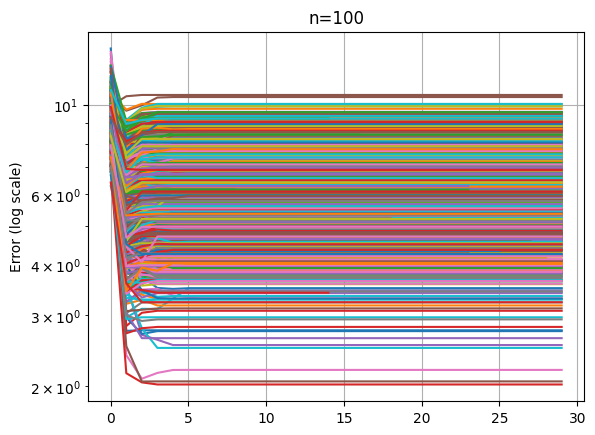

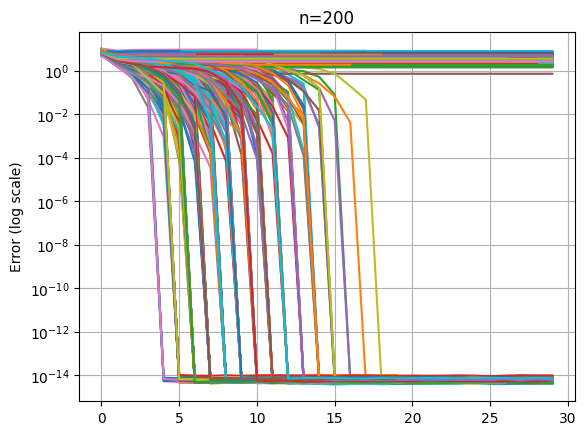

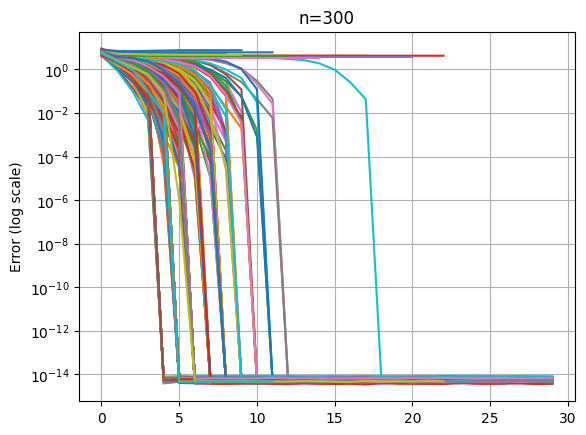

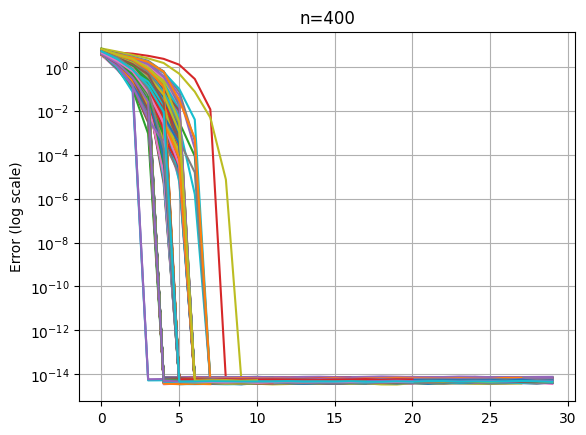

{0.0: 0, 0.1: 545, 0.2: 989, 0.30000000000000004: 1000}

In [218]:
n = 1000
d = 50
n_vals = np.arange(1, 5)*100
errors = []

for n in n_vals:
    n_error = []
    for j in range(1, 1001):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_spectral(y, A, niter=30)
        error = min_error(x_hat, x)
        n_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(n_error)
    plt.title(f'n={n}')
    plt.ylabel("Error (log scale)")
    plt.yscale('log')  
    plt.grid(True)
    plt.savefig(f'Convergence at n={n}.png') 
    plt.show()
convergence_counts(errors, n_vals)

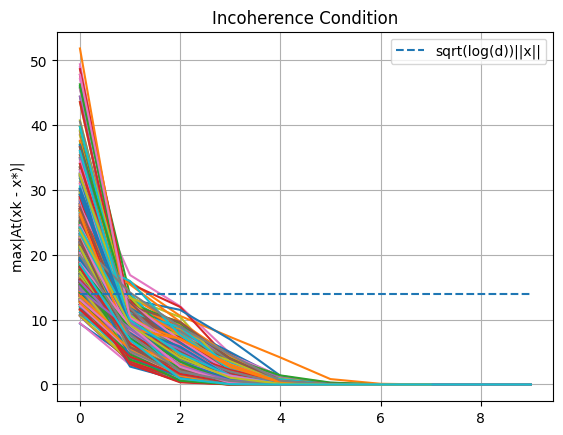

In [224]:
n = 400
d = 50

for j in range(1, 1001):  
    # Generate vectors
    x = np.ones(d)
    A = np.random.randn(d, n)
    y = np.square(A.T @ x)
        
    # Run the algorithm
    x_hat = bwgd_spectral(y, A, niter=10)

    # Incoherence condition
    at_x = []
    for x_k in x_hat:
        at_x.append(np.max(np.abs(A.T @ (x_k - x_hat[-1]))))
    
    # Plot results
    if min_error(x_hat, np.ones(d))[-1]>1e-8:
        plt.plot(at_x, label="wrong convergence")
    else:
        plt.plot(at_x)


plt.title("Incoherence Condition")
plt.ylabel("max|At(xk - x*)|")
plt.plot([np.sqrt(np.log(d)) * np.linalg.norm(np.ones(d))]*10, label = "sqrt(log(d))||x||", linestyle='--')
plt.legend()
plt.grid(True)
plt.savefig('Incoherence condition.png') 

**Phase transition**

In [209]:
# Implements BWDG over a stochastic Subspace with thresholding
def bwgd_threshold(y, A, alpha=0, niter = 50):
    d, n = A.shape 
    x = np.zeros((niter, d))  
    threshold = int(alpha * n)

    # Spectral initialization
    Y = (1 / n) * (A @ np.diag(y) @ A.T)
    eigenvals, eigenvects = np.linalg.eigh(Y)
    index = np.argmax(eigenvals)  
    x[0] = np.sqrt(eigenvals[index] / 3) * eigenvects[:, index]

    for iter in range(1, niter):
        # Find indices for smallest |AtX|
        sorted_indices = np.argsort(np.abs(A.T @ x[iter - 1]))
        indices = sorted_indices[threshold:]

        # Discard the selected indices
        A_filtered = A.T[indices].T.copy()
        y_filtered = y[indices].copy()

        # Covariance matrix transform
        C = A_filtered @ A_filtered.T / n
        C_sqrt = sqrtm(C)
        C_inv = np.real(inv(C_sqrt))
        A_tilde = C_inv @ A_filtered 
        x_tilde = C_sqrt @ x[iter - 1]
                
        # Hessian
        hessian = (A_tilde @ A_tilde.T) / n
        
        # Gradient
        At_x = A_tilde.T @ x_tilde  
        gradient = hessian @ x_tilde - A_tilde @ (np.sqrt(y_filtered) * At_x / (np.abs(At_x)*n))
        h = np.linalg.solve(hessian, gradient)

        x_tilde -= h

        x[iter] = C_inv @ x_tilde

        if np.linalg.norm(x[iter] - x[iter-1])<1e-14:
                return x[:iter]
        
    return x

In [210]:
from tqdm import tqdm
def phase_transition(samples, alphas, niter=100, d=50,):
    # Matrix for convergence in samples x alphas
    convergence = np.zeros((len(samples), len(alphas)))
    x_true = np.ones(d)
    
    for i, n in tqdm(enumerate(samples)):
        for j, alpha in enumerate(alphas):
            converged = 0
            for _ in range(niter):
                # Generate random samples A and response y
                A = np.random.randn(d, n)
                y = (A.T @ x_true)**2  
                
                # Run algorithm
                x_hat = bwgd_threshold(y, A, alpha)

                # Check for convergence
                if min_error(x_hat, x_true)[-1] < 1e-12:
                    converged += 1 

            convergence[i, j] = converged
            
    return convergence

In [211]:
samples = np.arange(100, 600, 100)  
alphas = np.arange(0, 10) * 0.1  
convergence = phase_transition(samples, alphas)

0it [00:00, ?it/s]C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  x[iter] = C_inv @ x_tilde
C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:39: RuntimeWarning: overflow encountered in matmul
  x[iter] = C_inv @ x_tilde
C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:39: RuntimeWarning: invalid value encountered in matmul
  x[iter] = C_inv @ x_tilde
C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:15: RuntimeWarning: invalid value encountered in matmul
  sorted_indices = np.argsort(np.abs(A.T @ x[iter - 1]))
C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:27: RuntimeWarning: invalid value encountered in matmul
  x_tilde = C_sqrt @ x[iter - 1]
C:\Users\gabreu\AppData\Local\Temp\ipykernel_32532\2739145607.py:34: RuntimeWarning: invalid value encountered in divide
  gradient = hessian @ x_tilde - A_tilde @ (np.sqrt(y_filtered) 

array([[  0.,   0.,   4.,   3.,   7.,   1.,   0.,   0.,   0.,   0.],
       [ 53.,  84.,  86.,  96.,  97.,  96.,  95.,  95.,   0.,   0.],
       [ 98.,  99., 100., 100., 100., 100., 100., 100., 100.,   0.],
       [100., 100., 100., 100., 100., 100., 100., 100., 100.,   0.],
       [100., 100., 100., 100., 100., 100., 100., 100., 100.,  80.]])

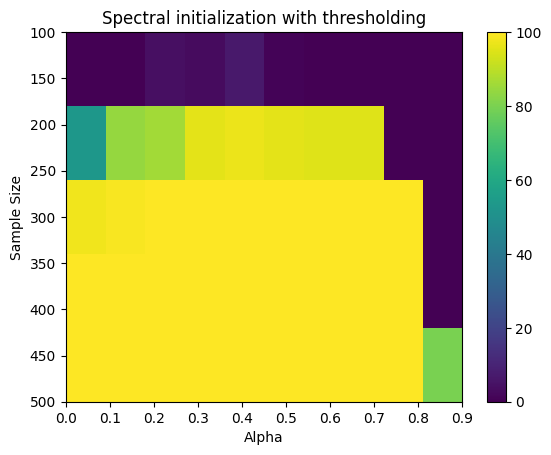

In [213]:
im = plt.imshow(convergence, extent=[alphas[0], alphas[-1], samples[-1], samples[0]], aspect='auto')
plt.colorbar()
plt.xlabel('Alpha')
plt.ylabel('Sample Size')
plt.title('Spectral initialization with thresholding')
convergence

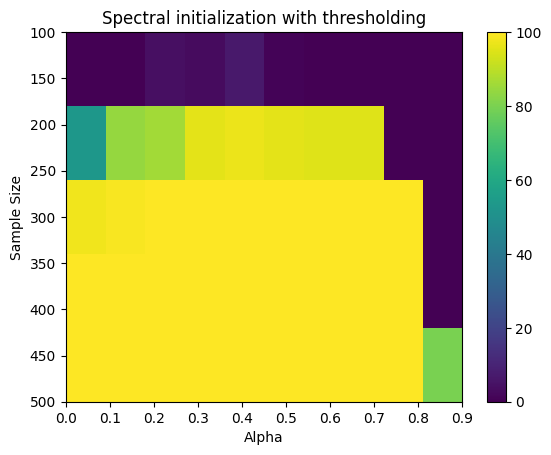

In [215]:
plt.imshow(convergence, extent=[alphas[0], alphas[-1], samples[-1], samples[0]], aspect='auto')
plt.colorbar()
plt.xlabel('Alpha')
plt.ylabel('Sample Size')
plt.title('Spectral initialization with thresholding')
plt.savefig('Phase Transitions.png') 